<a href="https://colab.research.google.com/github/bashar730/heart-disease-ai/blob/data-eda/notebooks/01_Data_Understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intelligent Heart Disease Risk Prediction and Medical Decision Support System

## Notebook 01 — Data Understanding and Exploratory Data Analysis

### Purpose
This notebook focuses on loading, understanding, validating, and exploring the UCI Heart Disease dataset before data preprocessing and model training.

### Main Tasks
- Load the official UCI Heart Disease dataset.
- Inspect dataset structure and variables.
- Identify missing and duplicate values.
- Analyze the original and binary target variables.
- Explore numerical and categorical features.
- Examine relationships between features and heart disease.

### Team Members
1.
2.
3.




## 2. Install and Import Libraries

This section installs and imports the Python libraries required for data loading, analysis, and visualization.

In [1]:
# Install UCI Machine Learning Repository package
!pip install -q ucimlrepo

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load Dataset

The official Heart Disease dataset is loaded from the UCI Machine Learning Repository using the `ucimlrepo` package.

In [3]:


# تحميل مجموعة Heart Disease الرسمية من UCI
heart_disease = fetch_ucirepo(id=45)

# الخصائص (Features)
X = heart_disease.data.features

# الهدف (Target)
y = heart_disease.data.targets

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 4. Dataset Overview

This section provides an initial overview of the dataset, including sample records, dataset dimensions, column names, data types, and descriptive statistics.

In [4]:
# Preview the first five rows of the features
display(X.head())

# Preview the first five rows of the target
display(y.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


,num
0,0
1,2
2,1
3,0
4,0


In [5]:
# Dataset dimensions

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (303, 13)
Target shape: (303, 1)


In [6]:
# عرض أسماء الأعمدة
print("Column names:")
print(X.columns.tolist())

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [7]:
# Data types and non-null values
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


In [8]:
# الإحصاءات الوصفية للبيانات
X.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


## 5. Data Quality Assessment

This section evaluates the quality of the dataset by checking for missing values and duplicate records before further analysis.

In [9]:
# حساب القيم المفقودة في كل عمود
# Check missing values in features
print("Missing values in each column:")
print(X.isnull().sum())

# Check missing values in target
print("\nMissing values in target:")
print(y.isnull().sum())

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

Missing values in target:
num    0
dtype: int64


In [10]:
# فحص عدد الصفوف المكررة
duplicate_rows = X.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


### Data Quality Observations

- Missing values are present in the `ca` and `thal` features.
- No duplicate rows were found in the feature dataset.
- Missing values will be handled during the data preprocessing stage.

## 6. Target Variable Analysis

This section analyzes the original target variable and converts it into a binary classification target suitable for predicting the presence or absence of heart disease.

In [11]:
# عرض القيم المختلفة في العمود الهدف
print("Unique target values:")
print(y["num"].unique())

# حساب عدد الحالات في كل فئة
print("\nTarget value counts:")
print(y["num"].value_counts().sort_index())

Unique target values:
[0 2 1 3 4]

Target value counts:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


### Original Target Interpretation

The original target variable (`num`) contains five values:

- `0` = No heart disease
- `1–4` = Presence of heart disease with different levels in the original dataset

For this project, the prediction problem is treated as a binary classification task:

- `0` = No Heart Disease
- `1` = Heart Disease

In [12]:
# إنشاء نسخة من العمود الهدف
y_binary = y.copy()

# 0 = No Heart Disease
# 1 = Heart Disease
# تحويل جميع القيم الأكبر من صفر إلى 1
y_binary["num"] = (y_binary["num"] > 0).astype(int)

print("Target converted successfully.")

Target converted successfully.


In [13]:
# Check binary target distribution
print("Binary target distribution:")
print(y_binary["num"].value_counts().sort_index())

Binary target distribution:
num
0    164
1    139
Name: count, dtype: int64


In [14]:
# دمج الخصائص مع الهدف الجديد
df = X.copy()

df["target"] = y_binary["num"]

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


### Binary Target Observation

After conversion, the dataset contains:

- 164 patients without heart disease.
- 139 patients with heart disease.

The two classes are relatively balanced, which is useful for subsequent exploratory analysis and machine learning experiments.

## 7. Feature Classification

The dataset features are grouped into numerical and categorical variables to support appropriate exploratory data analysis and visualization.

In [15]:
# الأعمدة الرقمية (Numerical Features)
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

# الأعمدة الفئوية (Categorical Features)
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Categorical Features:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [16]:
import seaborn as sns

print("Seaborn imported successfully.")

Seaborn imported successfully.


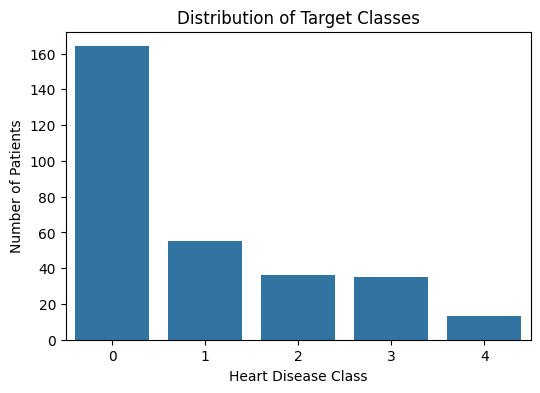

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x=y["num"])

plt.title("Distribution of Target Classes")
plt.xlabel("Heart Disease Class")
plt.ylabel("Number of Patients")

plt.show()

<div dir="rtl">

ماذا نستنتج؟

# يوضح الرسم البياني أن عدد المرضى غير المصابين (الفئة 0) هو الأعلى مقارنة ببقية الفئات، بينما يقل عدد المرضى تدريجيًا في الفئات التي تمثل درجات الإصابة المختلفة، وتعد الفئة 4 الأقل عددًا. يشير ذلك إلى أن توزيع البيانات غير متساوٍ بين جميع الفئات، وهو أمر يجب أخذه في الاعتبار عند بناء نموذج تعلم الآلة.

## 8. Exploratory Data Analysis (EDA)

This section explores the distribution of key features and their relationships with the binary heart disease target using visual analysis.

### 8.1 Age Analysis

The age feature is analyzed to understand its distribution, identify potential outliers, and examine its relationship with heart disease.

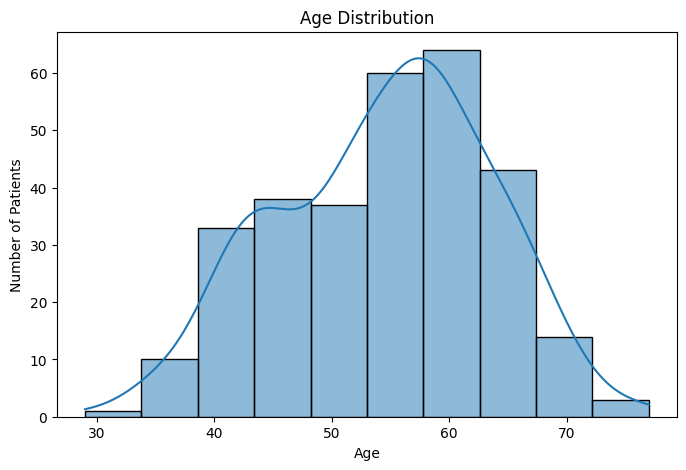

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(X["age"], bins=10, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

<div dir="rtl">

ماذا نستنتج؟
# يوضح الرسم البياني أن معظم المرضى في مجموعة البيانات ينتمون إلى الفئة العمرية المتوسطة إلى الكبيرة، حيث يتركز العدد الأكبر بين 55 و65 سنة، بينما يقل عدد المرضى في الأعمار الصغيرة جدًا وكذلك في الأعمار الكبيرة جدًا.


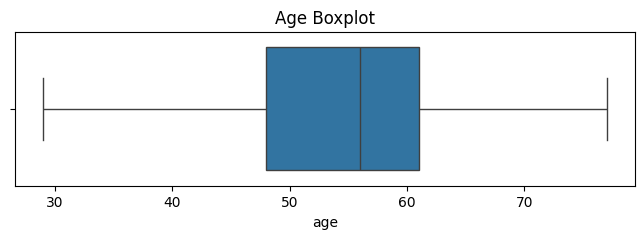

In [19]:
plt.figure(figsize=(8,2))

sns.boxplot(x=X["age"])

plt.title("Age Boxplot")

plt.show()

<div dir="rtl">

الاستنتاج العلمي
# يوضح الرسم البياني أن المرضى المصابين بمرض القلب يميلون إلى أن يكونوا أكبر عمرًا مقارنة بغير المصابين، حيث يظهر ارتفاع في الوسيط العمري للمجموعة المصابة. كما توجد حالة واحدة ذات عمر أقل من بقية المصابين، إلا أنها تمثل قيمة ممكنة طبيًا ولا تستدعي حذفها.

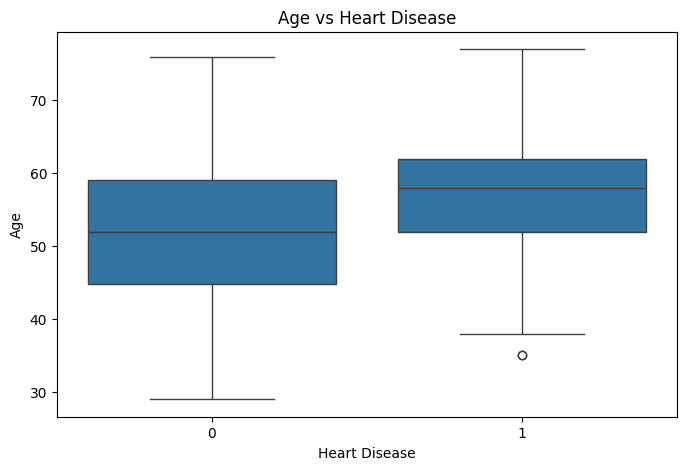

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(x="target", y="age", data=df)

plt.title("Age vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Age")

plt.show()

#### Age Observations

- Most patients are middle-aged or older adults.
- The age distribution does not show extreme outliers.
- Heart disease cases appear more frequently among older patients in this dataset.

### 8.2 Categorical Features Analysis

Categorical features are analyzed to examine how their categories are distributed between patients with and without heart disease.

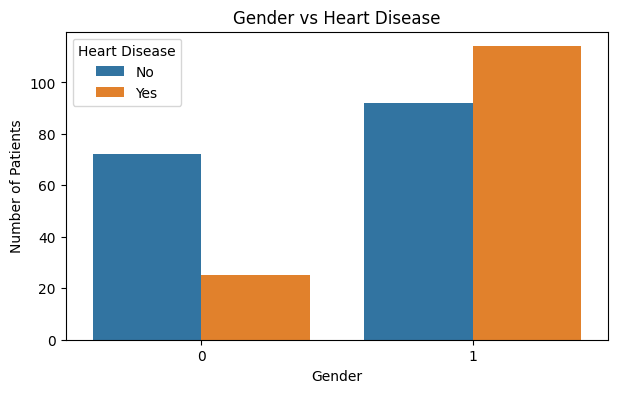

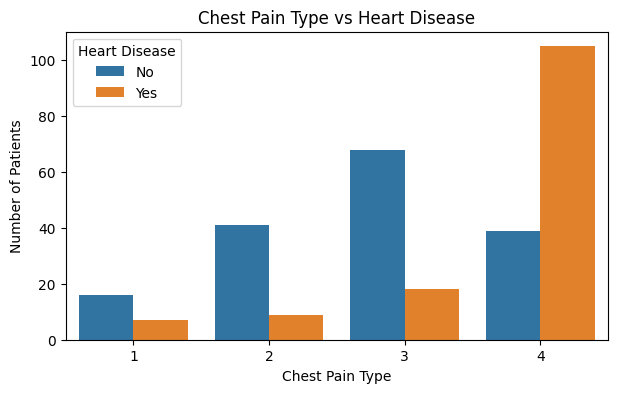

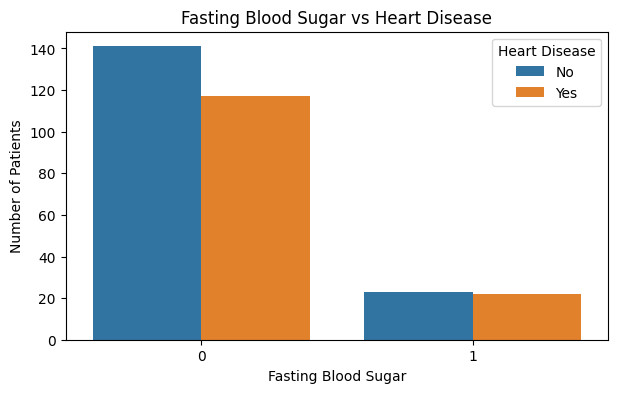

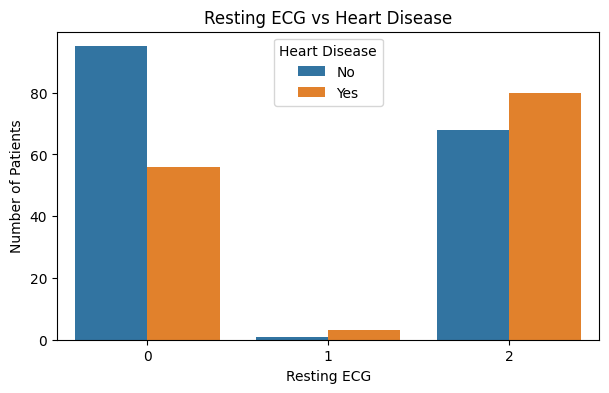

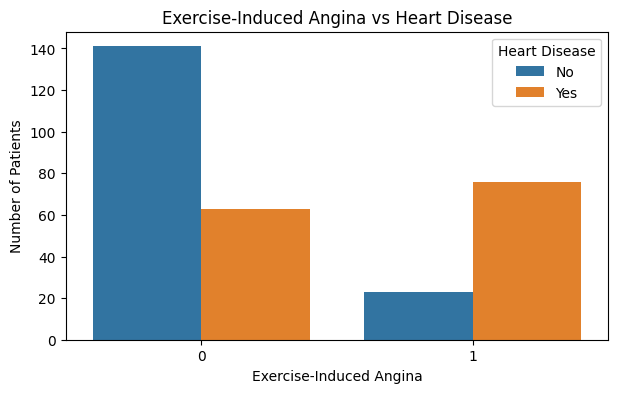

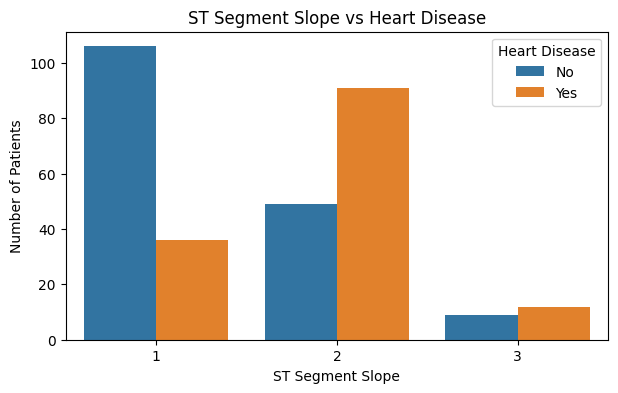

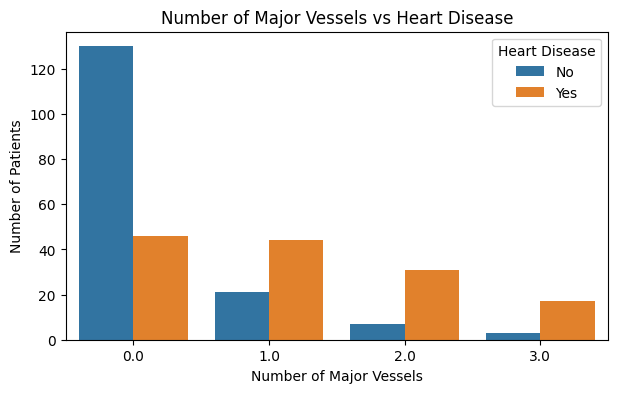

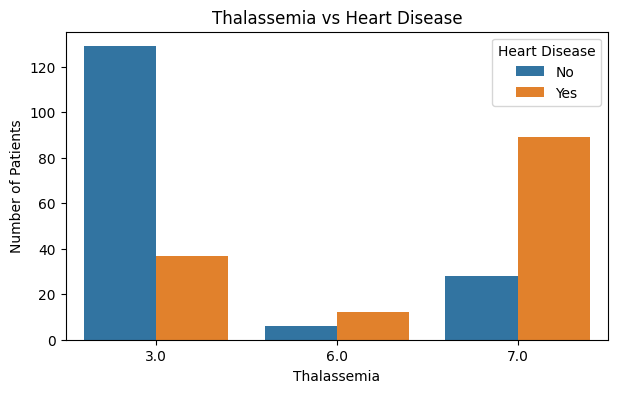

In [21]:

# Display names for categorical features
# أسماء احترافية ستظهر في عناوين الرسوم
feature_names = {
    "sex": "Gender",
    "cp": "Chest Pain Type",
    "fbs": "Fasting Blood Sugar",
    "restecg": "Resting ECG",
    "exang": "Exercise-Induced Angina",
    "slope": "ST Segment Slope",
    "ca": "Number of Major Vessels",
    "thal": "Thalassemia"
}

# رسم جميع الأعمدة الفئوية
for feature in categorical_features:

    plt.figure(figsize=(7,4))

    sns.countplot(x=feature, hue="target", data=df)

    plt.title(f"{feature_names[feature]} vs Heart Disease")

    plt.xlabel(feature_names[feature])
    plt.ylabel("Number of Patients")

    plt.legend(title="Heart Disease", labels=["No", "Yes"])

    plt.show()

## Observations from Categorical Features Analysis

### **Gender** (Sex)
- The number of male patients is higher than the number of female patients.
- Male patients show a higher number of heart disease cases compared to females.
- This observation should be interpreted considering that the
<div dir="rtl">

- عدد المرضى الذكور أعلى من عدد المرضى الإناث.
- أظهر المرضى الذكور عدداً أكبر من حالات الإصابة بأمراض القلب مقارنة بالإناث.
- يجب تفسير هذه الملاحظة مع الأخذ ببعين الاعتبار أن شريحة البحث تحتوي على نسبة أعلى من الذكور.
</div>

### **Chest Pain Type** (CP)
- Chest pain type 4 (Asymptomatic) has the highest number of heart disease cases.
- This suggests that the absence of typical chest pain does not necessarily indicate the absence of heart disease.
<div dir="rtl">

- ألم الصدر من النوع 4 (بدون أعراض - Asymptomatic) سجل أعلى عدد في حالات الإصابة بأمراض القلب.
- يشير ذلك إلى أن غياب ألم الصدر النموذجي لا يعني بالضرورة عدم وجود مرض بالقلب.
</div>

### **Fasting Blood Sugar** (FBS)
- Most patients have normal fasting blood sugar levels (FBS = 0).
- No clear difference is observed between patients with and without heart disease based on fasting blood sugar alone.
<div dir="rtl">

- معظم المرضى لديهم مستويات سكر صائم طبيعية (FBS = 0).
- لا يوجد فارق واضح بين المرضى المصابين وغير المصابين بأمراض القلب بناءً على سكر الدم الصائم وحده.
</div>

### **Resting** ECG
- Most patients belong to ECG categories 0 and 2.
- Patients with Resting ECG = 2 show a higher number of heart disease cases compared to category 0.
- Category 1 contains very few samples, making it difficult to draw reliable conclusions.
<div dir="rtl">

- معظم المرضى ينتمون إلى فئات تخطيط القلب (ECG) رقم 0 و 2.
- المرضى الذين لديهم قيمة تخطيط القلب = 2 يظهرون عدداً أكبر من حالات الإصابة بأمراض القلب مقارنة بالفئة 0.
- تحتوي الفئة 1 على عدد قليل جداً من العينات، مما يجعل من الصعب استخلاص نتائج موثوقة منها.
</div>

### **Exercise-Induced Angina**
- Patients with exercise-induced angina (Exang = 1) show a noticeably higher number of heart disease cases.
- Patients without exercise-induced angina (Exang = 0) are more likely to be free from heart disease.
- This feature appears to have a strong relationship with heart disease in the dataset.
<div dir="rtl">

الذبحة الصدرية الناتجة عن المجهود (Exercise-Induced Angina)
- المرضى الذين يعانون من الذبحة الصدرية الناتجة عن المجهود (Exang = 1) يظهرون عدداً أكبر بكثير من حالات الإصابة بأمراض القلب.
- المرضى الذين لا يعانون من الذبحة الصدرية الناتجة عن المجهود (Exang = 0) هم أكثر عرضة لعدم الإصابة بمرض القلب.
- تبدو هذه الخاصية ذات علاقة قوية بوجود مرض القلب في مجموعة البيانات.
</div>

### **ST Segment Slope**
- Most patients with ST Segment Slope = 1 do not have heart disease.
- Patients with ST Segment Slope = 2 show a higher number of heart disease cases.
- Category 3 contains relatively few samples, making its interpretation less reliable.
<div dir="rtl">

- معظم المرضى الذين لديهم ميل قطاع ST = 1 غير مصابين بمرض القلب.

- المرضى الذين لديهم ميل قطاع ST = 2 يظهرون عدداً أكبر من حالات الإصابة بمرض القلب.
- تحتوي الفئة 3 على عينات قليلة نسبياً، مما يجعل تفسيرها أقل موثوقية.
</div>

### **Number of Major Vessels** (CA)
- Most patients with CA = 0 do not have heart disease.
- Higher CA values are associated with a greater number of heart disease cases.
- This feature appears to have a strong relationship with heart disease in the dataset.
<div dir="rtl">
### **عدد الأوعية الدموية الرئيسية** (CA)

- معظم المرضى الذين لديهم قيمة CA = 0 غير مصابين بمرض القلب.

- ترتبط القيم الأعلى لـ CA بزيادة عدد حالات الإصابة بمرض القلب.
- تبدو هذه الخاصية ذات علاقة قوية بوجود مرض القلب في مجموعة البيانات.
</div>

### **Thalassemia**
- Most patients with Thal = 3 do not have heart disease.
- Patients with Thal = 7 show a considerably higher number of heart disease cases.
- Category 6 contains relatively few samples, making its interpretation less reliable.
<div dir="rtl">

- معظم المرضى الذين لديهم Thal = 3 غير مصابين بمرض القلب.

- المرضى الذين لديهم Thal = 7 يظهرون عدداً أكبر بكثير من حالات الإصابة بمرض القلب.
- تحتوي الفئة 6 على عينات قليلة نسبياً، مما يجعل تفسيرها أقل موثوقية.
</div>






### 8.3 Correlation Analysis

Correlation analysis is used to examine the relationships between dataset features and the binary heart disease target.

A correlation matrix and heatmap are used to identify positive and negative relationships between variables.

In [22]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

correlation_matrix

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.097542,0.104139,0.284946,0.208950,0.118530,0.148868,-0.393806,0.091661,0.203805,0.161770,0.362605,0.127389,0.223120
sex,-0.097542,1.000000,0.010084,-0.064456,-0.199915,0.047862,0.021647,-0.048663,0.146201,0.102173,0.037533,0.093185,0.380936,0.276816
cp,0.104139,0.010084,1.000000,-0.036077,0.072319,-0.039975,0.067505,-0.334422,0.384060,0.202277,0.152050,0.233214,0.265246,0.414446
trestbps,0.284946,-0.064456,-0.036077,1.000000,0.130120,0.175340,0.146560,-0.045351,0.064762,0.189171,0.117382,0.098773,0.133554,0.150825
chol,0.208950,-0.199915,0.072319,0.130120,1.000000,0.009841,0.171043,-0.003432,0.061310,0.046564,-0.004062,0.119000,0.014214,0.085164
fbs,0.118530,0.047862,-0.039975,0.175340,0.009841,1.000000,0.069564,-0.007854,0.025665,0.005747,0.059894,0.145478,0.071358,0.025264
restecg,0.148868,0.021647,0.067505,0.146560,0.171043,0.069564,1.000000,-0.083389,0.084867,0.114133,0.133946,0.128343,0.024531,0.169202
thalach,-0.393806,-0.048663,-0.334422,-0.045351,-0.003432,-0.007854,-0.083389,1.000000,-0.378103,-0.343085,-0.385601,-0.264246,-0.279631,-0.417167
exang,0.091661,0.146201,0.384060,0.064762,0.061310,0.025665,0.084867,-0.378103,1.000000,0.288223,0.257748,0.145570,0.329680,0.431894
oldpeak,0.203805,0.102173,0.202277,0.189171,0.046564,0.005747,0.114133,-0.343085,0.288223,1.000000,0.577537,0.295832,0.341004,0.424510


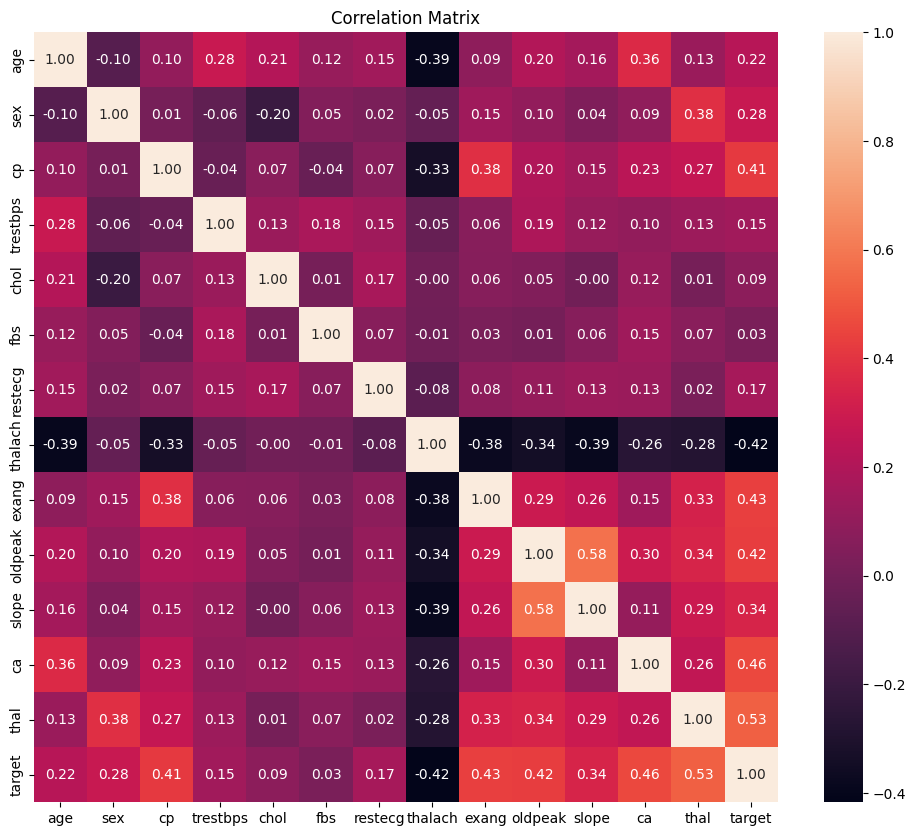

In [23]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

#### Correlation Analysis Observations

- `thal` shows the strongest positive correlation with the target (approximately 0.53).
- `ca`, `exang`, `oldpeak`, and `cp` also show noticeable positive correlations with heart disease.
- `thalach` shows the strongest negative correlation with the target (approximately -0.42).
- `fbs` and `chol` show very weak linear correlations with the target.
- `oldpeak` and `slope` show a relatively notable positive correlation with each other (approximately 0.58).
- Correlation indicates statistical association and does not imply causation.

In [24]:
# Sort feature correlations with the target
target_correlations = correlation_matrix["target"].drop("target")

target_correlations = target_correlations.reindex(
    target_correlations.abs().sort_values(ascending=False).index
)

print("Features ranked by correlation with target:")
print(target_correlations)

Features ranked by correlation with target:
thal        0.525689
ca          0.460442
exang       0.431894
oldpeak     0.424510
thalach    -0.417167
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
Name: target, dtype: float64


### 8.4 Key EDA Findings

The exploratory data analysis revealed several important patterns in the UCI Heart Disease dataset:

- The dataset contains 303 patient records and 13 input features.
- Missing values were identified in the `ca` and `thal` features, while no duplicate records were detected.
- After converting the original target into binary classes, the dataset contains 164 patients without heart disease and 139 patients with heart disease.
- Heart disease cases tend to occur more frequently among older patients in this dataset.
- Several categorical features, including chest pain type (`cp`), exercise-induced angina (`exang`), ST segment slope (`slope`), number of major vessels (`ca`), and `thal`, showed noticeable differences between patients with and without heart disease.
- Correlation analysis showed that `thal`, `ca`, `exang`, `oldpeak`, and `cp` had notable positive correlations with the target.
- `thalach` showed a notable negative correlation with the target.
- `fbs` and `chol` showed very weak linear correlations with the target.
- These findings represent exploratory associations and do not imply causation or clinical diagnosis.

## 9. Export Raw Dataset

The original UCI Heart Disease dataset is exported as a CSV file for storage and reproducibility.

In [25]:
# Create a copy of the original dataset
raw_data = X.copy()
raw_data["num"] = y["num"]

# Save as CSV
raw_data.to_csv("heart_disease_raw.csv", index=False)

print("Raw dataset saved successfully.")

Raw dataset saved successfully.
